In [42]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt

file_path = "interactions_clean.csv"

# UNCOMMENT THIS IF YOU ARE USING KAGGLE
#file_path = '/kaggle/input/datasets/djamelachour/student-question-interaction-data/interactions_clean.csv'

df = pd.read_csv('interactions_clean.csv')

df = df.drop(columns=['Response Time'])


df.head()

,Student ID,Question ID,difficulty,correct,topic
0,AQklHbi5bt8l,1,hard,0,Data Mining Tasks
1,AQklHbi5bt8l,2,easy,1,Similarity Measures
2,AQklHbi5bt8l,3,easy,1,Similarity Measures
3,AQklHbi5bt8l,4,easy,1,Similarity Measures
4,AQklHbi5bt8l,5,medium,0,Similarity Measures


In [43]:
df['student_avg_score'] = df.groupby('Student ID')['correct'].transform('mean')

df['student_questions_answered'] = df.groupby('Student ID')['Question ID'].transform('count')

df['student_topic_performance'] = df.groupby(['Student ID', 'topic'])['correct'].transform('mean')

diff_map = {'easy': 1, 'medium': 2, 'hard': 3}
df['difficulty'] = df['difficulty'].map(diff_map)

df['student_difficulty_tolerance'] = df[df['correct'] == 1].groupby('Student ID')['difficulty'].transform('mean')
# Fill NaNs for students who haven't answered anything correctly yet
df['student_difficulty_tolerance'] = df.groupby('Student ID')['student_difficulty_tolerance'].transform(lambda x: x.ffill().bfill().fillna(0))

df.head()

,Student ID,Question ID,difficulty,correct,topic,student_avg_score,student_questions_answered,student_topic_performance,student_difficulty_tolerance
0,AQklHbi5bt8l,1,3,0,Data Mining Tasks,0.716667,120,0.250000,1.104651
1,AQklHbi5bt8l,2,1,1,Similarity Measures,0.716667,120,0.857143,1.104651
2,AQklHbi5bt8l,3,1,1,Similarity Measures,0.716667,120,0.857143,1.104651
3,AQklHbi5bt8l,4,1,1,Similarity Measures,0.716667,120,0.857143,1.104651
4,AQklHbi5bt8l,5,2,0,Similarity Measures,0.716667,120,0.857143,1.104651


In [44]:
df.shape

(17340, 9)

In [45]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17340 entries, 0 to 17339
Data columns (total 9 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Student ID                    17340 non-null  object 
 1   Question ID                   17340 non-null  int64  
 2   difficulty                    17340 non-null  int64  
 3   correct                       17340 non-null  int64  
 4   topic                         17340 non-null  object 
 5   student_avg_score             17340 non-null  float64
 6   student_questions_answered    17340 non-null  int64  
 7   student_topic_performance     17340 non-null  float64
 8   student_difficulty_tolerance  17340 non-null  float64
dtypes: float64(3), int64(4), object(2)
memory usage: 1.2+ MB


### Encoding categorical features

In [47]:
from sklearn.preprocessing import OneHotEncoder

ohe = OneHotEncoder(sparse_output=False)
encoded = ohe.fit_transform(df[['topic']])  # Double brackets!
encoded_df = pd.DataFrame(encoded, columns=ohe.get_feature_names_out(['topic']))
df = pd.concat([df.drop('topic', axis=1), encoded_df], axis=1)

In [48]:
df.head()

,Student ID,Question ID,difficulty,correct,student_avg_score,student_questions_answered,student_topic_performance,student_difficulty_tolerance,topic_Apriori Algorithm,topic_Association Rules,...,topic_K-means Clustering,topic_Model Evaluation,topic_Overfitting & Regularization,topic_Principal Component Analysis,topic_Programming Tools (NumPy/Pandas),topic_Rule Metrics,topic_Scaling & Normalization,topic_Similarity Measures,topic_Time Series Data,topic_Unsupervised Learning
0,AQklHbi5bt8l,1,3,0,0.716667,120,0.250000,1.104651,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,AQklHbi5bt8l,2,1,1,0.716667,120,0.857143,1.104651,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2,AQklHbi5bt8l,3,1,1,0.716667,120,0.857143,1.104651,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,AQklHbi5bt8l,4,1,1,0.716667,120,0.857143,1.104651,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,AQklHbi5bt8l,5,2,0,0.716667,120,0.857143,1.104651,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


### Data Exploration

In [49]:
print('number of students: ', df['Student ID'].nunique())
print('number of questions: ', df['Question ID'].nunique())

number of students:  121
number of questions:  150


### label feature balance check

In [50]:
df['correct'].value_counts()

correct
1    13134
0     4206
Name: count, dtype: int64

### Data Splitting

#### Drop ID columns

In [51]:
df = df.drop(columns=['Student ID', 'Question ID'])

In [52]:
from sklearn.model_selection import train_test_split

# Drop student and question identifier features as requested
# Also dropping difficulty_num if it exists (it was used for feature engineering)
cols_to_drop = ['correct', 'Student ID', 'Question ID', 'difficulty_num']
X = df.drop(columns=[c for c in cols_to_drop if c in df.columns])
y = df['correct']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Features used: {X.columns.tolist()}")

Features used: ['difficulty', 'student_avg_score', 'student_questions_answered', 'student_topic_performance', 'student_difficulty_tolerance', 'topic_Apriori Algorithm', 'topic_Association Rules', 'topic_Classification', 'topic_Clustering Evaluation', 'topic_Cross-Validation', 'topic_DBSCAN', 'topic_Data Mining Tasks', 'topic_Data Preprocessing', 'topic_Data Types', 'topic_Decision Trees', 'topic_FP-growth', 'topic_Feature Extraction', 'topic_Feature Selection', 'topic_General', 'topic_Hierarchical Clustering', 'topic_K-means Clustering', 'topic_Model Evaluation', 'topic_Overfitting & Regularization', 'topic_Principal Component Analysis', 'topic_Programming Tools (NumPy/Pandas)', 'topic_Rule Metrics', 'topic_Scaling & Normalization', 'topic_Similarity Measures', 'topic_Time Series Data', 'topic_Unsupervised Learning']


In [53]:
print(f"Training set size: {len(X_train)} ({len(X_train)/len(X)*100:.1f}%)")
print(f"Test set size: {len(X_test)} ({len(X_test)/len(X)*100:.1f}%)")
print(f"Training - Class distribution:\n{y_train.value_counts(normalize=True).mul(100).round(1)}")
print(f"Test - Class distribution:\n{y_test.value_counts(normalize=True).mul(100).round(1)}")

Training set size: 13872 (80.0%)
Test set size: 3468 (20.0%)
Training - Class distribution:
correct
1    75.7
0    24.3
Name: proportion, dtype: float64
Test - Class distribution:
correct
1    75.7
0    24.3
Name: proportion, dtype: float64


In [54]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# ============ TRAINING SCRIPT ============
print("="*50)
print("TRAINING PROBABILISTIC CLASSIFIERS")
print("="*50)


# Initialize models
models = {
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Naive Bayes': GaussianNB()
}

# Train models
trained_models = {}
for name, model in models.items():
    print(f"\nTraining {name}...")
    trained_models[name] = model.fit(X_train, y_train)
    print(f"{name} trained successfully!")

# ============ EVALUATION SCRIPT ============
print("\n" + "="*50)
print("EVALUATION WITH PREDICTION CERTAINTY")
print("="*50)

results = {}

for name, model in trained_models.items():
    print(f"\n{'='*40}")
    print(f"MODEL: {name}")
    print('='*40)
    
    # Predict classes and probabilities
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)
    
    # Get max probability (certainty) for each prediction
    certainty = np.max(y_proba, axis=1)
    avg_certainty = certainty.mean() * 100
    
    # Evaluation metrics
    accuracy = accuracy_score(y_test, y_pred)
    
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Average prediction certainty: {avg_certainty:.2f}%")
    print(f"\nClassification Report:")
    print(classification_report(y_test, y_pred))
    
    # Store results
    results[name] = {
        'accuracy': accuracy,
        'avg_certainty': avg_certainty,
        'y_pred': y_pred,
        'y_proba': y_proba,
        'certainty': certainty
    }
    
    # Show first 10 predictions with certainty
    print(f"\nFirst 10 predictions with certainty:")
    for i in range(min(10, len(y_test))):
        pred_class = y_pred[i]
        true_class = y_test.iloc[i] if hasattr(y_test, 'iloc') else y_test[i]
        cert = certainty[i] * 100
        print(f"  Sample {i+1}: Predicted={pred_class}, Actual={true_class}, Certainty={cert:.1f}%")

# ============ COMPARISON SUMMARY ============
print("\n" + "="*50)
print("MODEL COMPARISON SUMMARY")
print("="*50)
comparison_df = pd.DataFrame({
    'Model': list(results.keys()),
    'Accuracy': [results[m]['accuracy'] for m in results],
    'Avg Certainty (%)': [results[m]['avg_certainty'] for m in results]
})
print(comparison_df.to_string(index=False))

# Best model by accuracy
best_model = comparison_df.loc[comparison_df['Accuracy'].idxmax(), 'Model']
print(f"\n🏆 Best model by accuracy: {best_model}")

# Function to get certainty for a single prediction
def predict_with_certainty(model, sample):
    proba = model.predict_proba([sample])[0]
    pred = model.predict([sample])[0]
    certainty = max(proba) * 100
    return pred, certainty, proba

print("\n✅ Ready to use predict_with_certainty(model, sample)")

TRAINING PROBABILISTIC CLASSIFIERS

Training Random Forest...


Random Forest trained successfully!

Training Logistic Regression...
Logistic Regression trained successfully!

Training Naive Bayes...
Naive Bayes trained successfully!

EVALUATION WITH PREDICTION CERTAINTY

MODEL: Random Forest
Accuracy: 0.8307
Average prediction certainty: 89.47%

Classification Report:
              precision    recall  f1-score   support

           0       0.68      0.57      0.62       841
           1       0.87      0.91      0.89      2627

    accuracy                           0.83      3468
   macro avg       0.77      0.74      0.76      3468
weighted avg       0.82      0.83      0.83      3468


First 10 predictions with certainty:
  Sample 1: Predicted=0, Actual=0, Certainty=81.1%
  Sample 2: Predicted=1, Actual=1, Certainty=100.0%
  Sample 3: Predicted=1, Actual=1, Certainty=100.0%
  Sample 4: Predicted=1, Actual=1, Certainty=100.0%
  Sample 5: Predicted=1, Actual=1, Certainty=92.3%
  Sample 6: Predicted=1, Actual=1, Certainty=99.0%
  Sample 7: Predic

In [55]:
import pickle

# Save the best model
best_model_name = comparison_df.loc[comparison_df['Accuracy'].idxmax(), 'Model']
model_to_save = trained_models[best_model_name]

models_dir = 'models'
if not os.path.exists(models_dir):
    os.makedirs(models_dir)

model_file_path = os.path.join(models_dir, 'model.pkl')
with open(model_file_path, 'wb') as f:
    pickle.dump(model_to_save, f)

print(f"✅ Best model ({best_model_name}) saved to {model_file_path}")

✅ Best model (Logistic Regression) saved to models\model.pkl


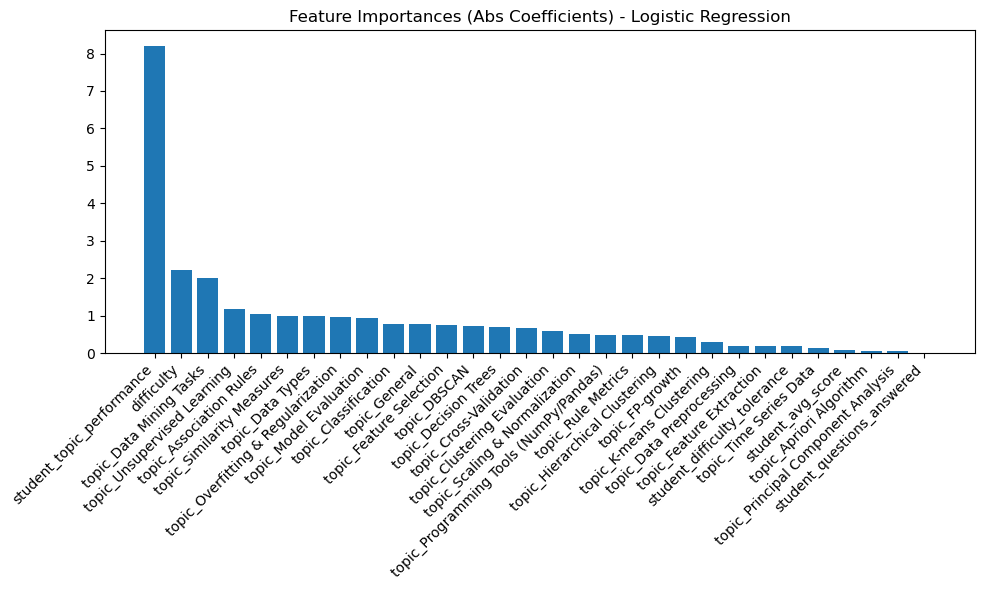

In [58]:
import matplotlib.pyplot as plt

feature_names = X.columns
plt.figure(figsize=(10, 6))

if hasattr(model_to_save, 'feature_importances_'):
    # For Random Forest
    importances = model_to_save.feature_importances_
    indices = np.argsort(importances)[::-1]
    plt.title(f"Feature Importances (MDI) - {best_model_name}")
    plt.bar(range(X.shape[1]), importances[indices], align="center")
    plt.xticks(range(X.shape[1]), feature_names[indices], rotation=45, ha='right')

elif hasattr(model_to_save, 'coef_'):
    # For Logistic Regression (showing absolute coefficients)
    importances = np.abs(model_to_save.coef_[0])
    indices = np.argsort(importances)[::-1]
    plt.title(f"Feature Importances (Abs Coefficients) - {best_model_name}")
    plt.bar(range(X.shape[1]), importances[indices], align="center")
    plt.xticks(range(X.shape[1]), feature_names[indices], rotation=45, ha='right')
else:
    print(f"The best model ({best_model_name}) does not support direct importance visualization.")

plt.tight_layout()
plt.show()